# 02. 모델링

## 문제 정의

EDA에서 연령과 직업군이 강하게 얽혀 있음을 확인했다.
단순 집계로는 어느 변수의 효과인지 분리할 수 없으므로,
두 변수를 동시에 투입한 모델로 각각의 순효과를 추정한다.

**목표변수**: 연금·저축 상품 가입 여부 (is_savings)
**목적**: 예측 성능이 아니라 변수별 기여도 추정 (교란 분리)

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)

ROOT = pathlib.Path.cwd().parent
FIG  = ROOT / "figures"

ins = pd.read_csv(ROOT / "data_processed.csv", encoding="utf-8-sig")
print(ins.shape)

(77305, 25)


## 1. 데이터 준비

범주형 변수만 사용하므로 원핫 인코딩을 적용한다.
금액 컬럼(transaction_amt, product_amt)은 EDA에서 확인한
데이터 품질 문제로 제외한다.

In [2]:
ins["is_savings"] = (ins["cat"] == "연금·저축").astype(int)

FEAT = ["age", "gender", "region", "income_bracket", "occupation_group",
        "credit_rating", "marital_status", "disease_history"]

X, y = ins[FEAT], ins["is_savings"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                      stratify=y, random_state=42)

print(f"양성 비율: {y.mean():.3f}")
print(f"학습 {len(Xtr):,} / 검증 {len(Xte):,}")

양성 비율: 0.149
학습 61,844 / 검증 15,461


## 2. 평가 지표 선정

양성 비율이 14.9%로 불균형하다. 정확도를 사용하면 모든 샘플을
음성으로 예측해도 85%가 나오므로 부적절하다.

- **ROC-AUC**: 양성과 음성의 순위 분리 능력
- **PR-AUC**: 불균형 데이터에서 양성 탐지 성능. 무작위 기준선이 양성 비율(0.149)과 같아 해석이 명확

두 지표를 함께 사용하고, 무작위 예측 모델을 기준선으로 둔다.

In [3]:
enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), FEAT)])

models = {
    "기준선(무작위)": Pipeline([
        ("enc", enc),
        ("clf", DummyClassifier(strategy="stratified", random_state=42))]),
    "로지스틱 회귀": Pipeline([
        ("enc", enc),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "로지스틱 + 교차항": Pipeline([
        ("enc", enc),
        ("int", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "랜덤포레스트": Pipeline([
        ("enc", enc),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                       class_weight="balanced",
                                       random_state=42, n_jobs=-1))]),
}

rows, fitted = [], {}
for nm, pipe in models.items():
    pipe.fit(Xtr, ytr)
    p = pipe.predict_proba(Xte)[:, 1]
    rows.append({"모델": nm,
                 "ROC-AUC": round(roc_auc_score(yte, p), 3),
                 "PR-AUC": round(average_precision_score(yte, p), 3)})
    fitted[nm] = pipe

perf = pd.DataFrame(rows)
print(perf.to_string(index=False))

        모델  ROC-AUC  PR-AUC
  기준선(무작위)    0.502   0.149
   로지스틱 회귀    0.709   0.288
로지스틱 + 교차항    0.727   0.333
    랜덤포레스트    0.740   0.355


## 3. 모델별 성능 비교

| 모델 | ROC-AUC | PR-AUC |
|---|---|---|
| 기준선(무작위) | 0.502 | 0.149 |
| 로지스틱 회귀 | 0.709 | 0.288 |
| 로지스틱 + 교차항 | 0.727 | 0.333 |
| 랜덤포레스트 | 0.740 | 0.355 |

**해석**

- 모든 모델이 기준선을 상회하여, 인구통계 변수가 상품 선택을 부분적으로 설명함을 확인
- 교차항 추가 시 PR-AUC가 0.288 → 0.333으로 15.6% 개선.
  이는 변수 간 상호작용이 존재함을 시사하며, EDA에서 관찰한
  "연령 효과가 직업군마다 다르게 나타나는 현상"과 일치
- 랜덤포레스트가 가장 높으나 교차항 로지스틱과의 차이는 크지 않아,
  성능 향상의 주된 요인은 비선형성보다 상호작용으로 판단
- 절대적 성능은 높지 않다. 인구통계 정보만으로는 설명에 한계가 있으며,
  이는 4장 한계에서 다룬다

## 4. 변수별 기여도

본 분석의 핵심 목적이다. 로지스틱 회귀 계수를 오즈비로 변환하여
다른 변수를 통제한 상태에서 각 범주의 순효과를 확인한다.

오즈비 = 해당 범주가 연금·저축 가입 가능성에 미치는 배수
(1보다 크면 증가, 작으면 감소)

In [4]:
pipe = fitted["로지스틱 회귀"]
names = pipe.named_steps["enc"].get_feature_names_out()
coef = pipe.named_steps["clf"].coef_[0]

odds = (pd.DataFrame({"변수": names, "계수": coef, "오즈비": np.exp(coef)})
          .assign(변수=lambda d: d["변수"].str.replace("oh__", "", regex=False)))

age_od = odds[odds["변수"].str.startswith("age_")].sort_values("오즈비", ascending=False)
occ_od = odds[odds["변수"].str.startswith("occupation_group_")].sort_values("오즈비", ascending=False)

print("[연령대]"); print(age_od[["변수","오즈비"]].round(3).to_string(index=False))
print(f"→ 최대/최소 = {age_od['오즈비'].max()/age_od['오즈비'].min():.2f}배\n")
print("[직업군]"); print(occ_od[["변수","오즈비"]].round(3).to_string(index=False))
print(f"→ 최대/최소 = {occ_od['오즈비'].max()/occ_od['오즈비'].min():.2f}배")

[연령대]
     변수   오즈비
age_20대 1.153
age_50대 1.075
age_30대 0.994
age_40대 0.915
age_70대 0.834
age_60대 0.822
→ 최대/최소 = 1.40배

[직업군]
                               변수   오즈비
           occupation_group_사무종사자 1.378
         occupation_group_비경제활동인구 1.161
             occupation_group_관리자 1.059
           occupation_group_판매종사자 1.056
         occupation_group_서비스 종사자 0.967
    occupation_group_전문가 및 관련 종사자 0.948
occupation_group_장치·기계조작 및 조립 종사자 0.723
              occupation_group_기타 0.651
→ 최대/최소 = 2.12배


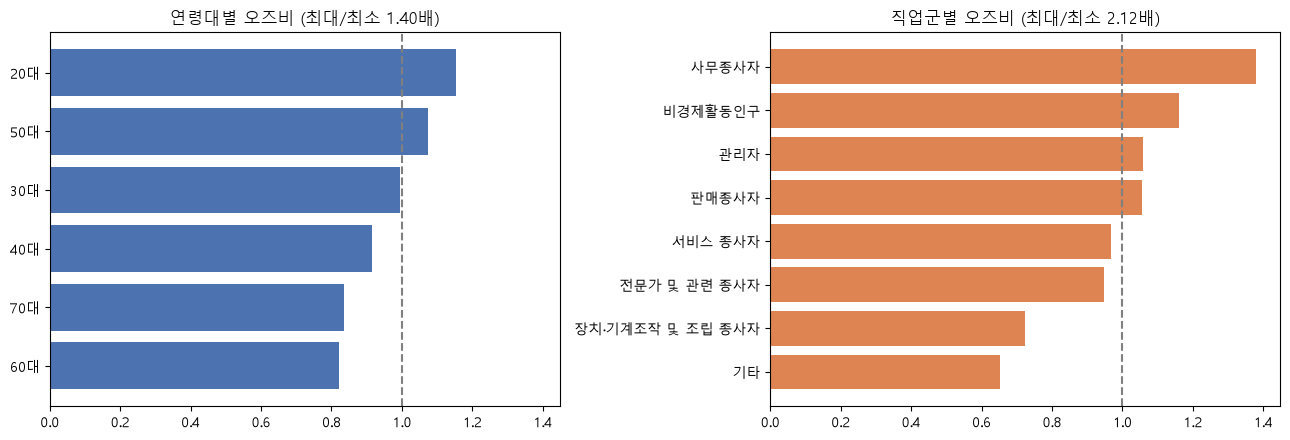

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

for a, d, t, c in [(ax[0], age_od, "연령대", "#4C72B0"),
                   (ax[1], occ_od, "직업군", "#DD8452")]:
    d2 = d.copy()
    d2["변수"] = d2["변수"].str.split("_").str[-1]
    a.barh(d2["변수"], d2["오즈비"], color=c)
    a.axvline(1.0, ls="--", c="gray")
    a.set_title(f"{t}별 오즈비 (최대/최소 {d['오즈비'].max()/d['오즈비'].min():.2f}배)")
    a.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG / "07_oddsratio.png", dpi=150, bbox_inches="tight")
plt.show()

marital       0.040
gender        0.046
income        0.046
age           0.054
credit        0.058
region        0.068
occupation    0.118
disease       0.570


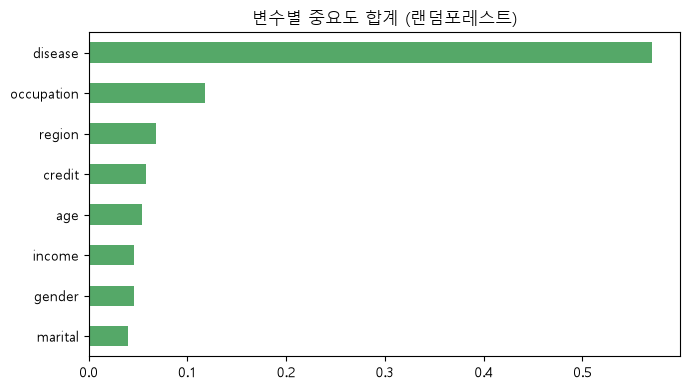

In [6]:
rf = fitted["랜덤포레스트"]
imp = pd.Series(rf.named_steps["clf"].feature_importances_,
                index=rf.named_steps["enc"].get_feature_names_out())
imp.index = imp.index.str.replace("oh__", "", regex=False)

by_var = imp.groupby(imp.index.str.split("_").str[0]).sum().sort_values()
print(by_var.round(3).to_string())

by_var.plot(kind="barh", figsize=(7, 4), color="#55A868")
plt.title("변수별 중요도 합계 (랜덤포레스트)")
plt.tight_layout()
plt.savefig(FIG / "08_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**해석**

다른 변수를 통제한 상태에서 각 변수의 순효과는 다음과 같다.

- **연령대**: 20대 1.153 ~ 60대 0.822 (최대/최소 1.40배)
- **직업군**: 사무종사자 1.378 ~ 장치·기계조작 0.723 (1.90배)

직업군의 효과 폭이 연령대의 1.4배에 달한다.

주목할 점은 EDA 단순 집계에서 연금·저축 비중이 20대 20.8%,
60대 12.2%로 1.7배 차이를 보였으나, 직업군을 통제하자 오즈비 기준
1.4배로 축소되었다는 것이다. 즉 관찰된 연령 차이의 일부는
연령 자체의 효과가 아니라 연령대별 직업 구성 차이에서 기인한다.

한편 연령 오즈비는 단조 감소하지 않는다(50대 1.075 > 30대 0.994).
직업 구성을 통제하면 연령의 선형적 영향은 약해지며,
이는 연령이 독립적 결정 요인이라기보다 직업 구성의 대리 지표에
가까움을 시사한다.

In [7]:
print(ins["disease_history"].value_counts())
print(pd.crosstab(ins["disease_history"], ins["cat"], normalize="index").round(3) * 100)
print(pd.crosstab(ins["disease_history"], ins["is_savings"], normalize="index").round(3) * 100)

disease_history
없음                        23686
근골격계+척추계                   8392
근골격계                       5528
기타                         5447
근골격계+척추계+호흡기계              3803
관절계+근골격계+척추계               2737
호흡기계                       2569
근골격계+호흡기계                  2059
관절계+근골격계                   2017
근골격계+소화기용종+척추계             2010
근골격계+뇌질환계                  1551
관절계+근골격계+척추계+호흡기계          1545
근골격계+소화기용종                 1432
소화기용종                      1381
근골격계+뇌질환계+척추계              1337
근골격계+소화기용종+척추계+호흡기계         858
안과계                         825
관절계+근골격계+소화기용종+척추계          801
근골격계+안과계+척추계                792
근골격계+안과계+척추계+호흡기계           719
근골격계+뇌질환계+척추계+치아계           715
근골격계+뇌질환계+척추계+호흡기계          672
산부인과계                       672
관절계+근골격계+호흡기계               642
관절계+근골격계+뇌질환계+척추계           617
근골격계+뇌질환계+치아계               601
내부장기계                       555
근골격계+내부장기계+척추계+호흡기계         529
근골격계+신경정신계+척추계+호흡기계         494
심혈관계                        467
근골격계+심혈관계+척추계           

In [8]:
ins["has_disease"] = (ins["disease_history"] != "없음").astype(int)
print(ins.groupby("has_disease")["is_savings"].agg(["mean","count"]).round(3))

              mean  count
has_disease              
0            0.279  23686
1            0.091  53619


In [9]:
FEAT2 = ["age", "gender", "region", "income_bracket",
         "occupation_group", "credit_rating", "marital_status", "has_disease"]

X2 = ins[FEAT2]
X2tr, X2te, ytr, yte = train_test_split(X2, y, test_size=0.2, stratify=y, random_state=42)

enc2 = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), FEAT2)])
rf2 = Pipeline([("enc", enc2),
                ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                               class_weight="balanced",
                                               random_state=42, n_jobs=-1))]).fit(X2tr, ytr)

imp = pd.Series(rf2.named_steps["clf"].feature_importances_,
                index=rf2.named_steps["enc"].get_feature_names_out())
imp.index = imp.index.str.replace("oh__", "", regex=False)
print(imp.groupby(imp.index.str.split("_").str[0]).sum().sort_values(ascending=False).round(3))

p = rf2.predict_proba(X2te)[:, 1]
print(f"ROC-AUC {roc_auc_score(yte,p):.3f}, PR-AUC {average_precision_score(yte,p):.3f}")

has           0.536
occupation    0.125
region        0.082
age           0.064
credit        0.060
income        0.050
gender        0.046
marital       0.038
dtype: float64
ROC-AUC 0.731, PR-AUC 0.354


In [10]:
FEAT3 = [f for f in FEAT2 if f != "has_disease"]
X3 = ins[FEAT3]
X3tr, X3te, _, _ = train_test_split(X3, y, test_size=0.2, stratify=y, random_state=42)

enc3 = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), FEAT3)])
rf3 = Pipeline([("enc", enc3),
                ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                               class_weight="balanced",
                                               random_state=42, n_jobs=-1))]).fit(X3tr, ytr)

imp3 = pd.Series(rf3.named_steps["clf"].feature_importances_,
                 index=rf3.named_steps["enc"].get_feature_names_out())
imp3.index = imp3.index.str.replace("oh__", "", regex=False)
g3 = imp3.groupby(imp3.index.str.split("_").str[0]).sum().sort_values(ascending=False)
print(g3.round(3).to_string())
print(f"\noccupation/age = {g3['occupation']/g3['age']:.2f}배")

occupation    0.290
region        0.183
age           0.129
credit        0.122
gender        0.099
income        0.098
marital       0.079

occupation/age = 2.25배


## 5. 결론 검증

핵심 비교(연령 vs 직업군)가 특정 방법론에 의존하지 않음을 확인한다.

| 방법 | 직업군/연령 비율 |
|---|---|
| EDA 격차 비교 | 1.67배 (12.2%p / 7.3%p) |
| 로지스틱 오즈비 | 2.12배 |
| RF 변수 중요도 (유병 여부 포함) | 2.00배 |
| RF 변수 중요도 (유병 여부 제외) | 2.25배 |

네 가지 서로 다른 접근이 모두 동일한 방향을 가리킨다.
직업군은 연령 대비 약 2배의 설명력을 가지며, 이는 모델 선택이나
변수 구성과 무관하게 일관된다.

## 6. 한계와 개선 방향

### 데이터 한계

- **단일 보험사 데이터**: 상품 구성이 특정사 라인업에 한정되어 시장 전체로 일반화할 수 없다. 특히 해당사가 변액·연금 상품에 강점이 있어 저축성 비중이 시장 평균보다 높을 가능성이 있다.
- **가입자 데이터만 존재**: 비가입자가 없어 가입률이나 제안 성사율을 계산할 수 없다. "어떤 집단이 가입할 확률이 높은가"가 아니라 "가입자 중 어떤 상품을 선택했는가"만 분석 가능하다.
- **금액 컬럼 사용 불가**: `transaction_amt`가 10만원 단위로 구간화되어 있고 카테고리별 중앙값이 통상적 보험료 구조와 상반되어, 금액 축 분석을 배제했다.
- **연령 라벨의 시점**: `age`가 현재 연령이므로 가입 시점 연령과 다를 수 있다. 다만 계약의 95% 이상이 2023년 이후로 확인되어 영향은 제한적이다.
- **고연령 직업 라벨**: 사무종사자 60대의 소득 3000만원 미만 비율이 26.6%로 50대(5.3%)의 5배에 달해, 정년 후 집단 구성 변화가 의심된다. 결론은 20~40대 중심으로 해석했다.

### 모델 한계

- **절대 성능이 낮다** (ROC-AUC 0.73). 인구통계 변수만으로 상품 선택을 예측하는 데는 구조적 한계가 있다. 실제 선택은 판매 채널, 설계사, 가입 시점의 캠페인 등 데이터에 없는 요인에 크게 좌우될 것으로 추정된다.
- **유병 여부의 인과 방향 불명**: 변수 중요도 53.6%로 가장 높으나, 가입 시점 고지 정보일 가능성이 있어 "질병이 없어 저축성을 택했다"인지 "저축성을 택해 고지할 질병이 없었다"인지 구분할 수 없다.
- **이진 분류로 단순화**: 6개 카테고리 중 연금·저축 여부만 모델링했다. 다중 분류로 확장하면 상품별 결정 요인을 세분화할 수 있다.

### 개선 방향

- 판매 채널·설계사 정보 확보 시 설명력이 크게 개선될 것으로 예상
- `region`의 변수 중요도가 연령을 상회(0.183 vs 0.129)하여, 지역 축에 대한 추가 분석 여지가 있다
- 계약 유지·해지 데이터가 확보되면 "선택"이 아닌 "성과" 관점 분석이 가능하다